# Overview - Validation Phase 2

> **Phase 2 — Validation** | This notebook is part of a two-phase credit risk model development and validation project.    Phase 2 applies and extends the methodology from Phase 1 to a larger dataset of 45,000 observations.

## Overview of Phase 2 Validation

This notebook independently validates the logistic regression model developed in Phase 2 Notebooks 1 and 2. It directly compares findings to Phase 1 validation to test whether the methodology generalises effectively at scale.

The project is divided into two parts:

1. EDA and Data Transformation
2. Modeling and Risk Analysis

The dataset used in this project was obtained from: https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data/data and contains demographic and financial information for 45,000 loan applicants.

### Approach

This notebook follows the same IRB validation methodology as Phase 1, with the addition of an explicit cross-phase comparison and overfitting check.

The following steps are performed:

- Performance baseline: AUC, Gini, KS statistic compared against Phase 1 results and IRB thresholds
- Cross-phase comparison table confirming methodology generalises effectively
- Calibration curve and Brier score
- Backtesting across probability bins
- Population Stability Index (PSI)
- Overfitting check: training vs test AUC gap
- Model stability: performance impact of removing previous_loan_defaults_on_file_Yes compared to Phase 1 Credit_History removal
- Risk segmentation review and expected loss concentration analysis

### Business Context

Independent model validation is a regulatory requirement under IRB frameworks. Phase 2 validation additionally serves to confirm that the two-phase project achieves its core objective — demonstrating that a credit risk methodology developed on a small dataset generalises effectively when applied to a larger and richer dataset.

### Key Validation Findings

- AUC 0.957, Gini 0.914, KS 0.770, all exceed IRB thresholds, substantial improvement over Phase 1
- Brier score 0.070 and PSI 0.0015,  strong calibration and stability
- No overfitting: train/test AUC gap of -0.002 (Tested in Notebook 2 as part deciding model to use)
- Dominant feature removal reduces AUC from 0.957 to 0.863. Model remains functional, contrasting with Phase 1 collapse to 0.595
- High Risk applicants account for 92.7% of total expected loss

### Important Note

The target variable is loan approval status, not observed default. This is an application scorecard — true PD validation would require post-approval repayment data. All validation findings should be interpreted in this context.

### References

- Muhammad Faizin Zen — Building a Credit Score Model series (Medium, 2025)
- Louis Deconinck — Credit Risk Modelling: Probability of Default (Kaggle, 2023)
- Basel II Glossary — Loss Given Default (2013)
- EBA Guidelines on non-discriminatory credit models
- GDPR Article 22 — Automated individual decision-making

### Table of Contents

1. Overview
2. Packages Used
3. Downloading and Standardizing Data
4. Model Performance Baseline
   - 4.1 Comparison to Phase1 
5. Calibration Curve
6. Brier Score
7. Backtest
8. Risk Segmentation
9. PSI
10. Overfitting Check
11. Model Stability — previous_loan_defaults_on_file_Yes Removal
12. Validation Conclusion

# 2. Packages used

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, classification_report,roc_curve 
from sklearn.metrics import f1_score, brier_score_loss
from sklearn.calibration import calibration_curve

import joblib

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# 3. Downloading Data and Model

In [2]:
X_train = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project2\train_data\X_train.csv")
X_test = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project2\test_data\X_test.csv")

y_train = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project2\train_data\y_train.csv").squeeze()
y_test = pd.read_csv(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\Data_Project2\test_data\y_test.csv").squeeze()

pipeline = joblib.load(r"C:\Users\Julia\OneDrive\Asiakirjat\Datasets_Loandata\models_project2\pd_model.pkl")

In [3]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 25 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   person_income                       36000 non-null  float64
 1   person_emp_exp                      36000 non-null  int64  
 2   loan_amnt                           36000 non-null  float64
 3   loan_int_rate                       36000 non-null  float64
 4   loan_percent_income                 36000 non-null  float64
 5   cb_person_cred_hist_length          36000 non-null  float64
 6   credit_score                        36000 non-null  int64  
 7   person_income_log                   36000 non-null  float64
 8   person_emp_exp_log                  36000 non-null  float64
 9   loan_amnt_win                       36000 non-null  float64
 10  loan_percent_income_win             36000 non-null  float64
 11  cb_person_cred_hist_length_win      36000

In [4]:
X_test_model = X_test.copy().drop(["person_income", "person_emp_exp", "loan_amnt", 
                                   "loan_percent_income", "cb_person_cred_hist_length"], axis=1)
X_test_true = X_test.copy().drop(["person_income_log", "person_emp_exp_log", "loan_amnt_win", 
                                   "loan_percent_income_win", "cb_person_cred_hist_length_win"], axis=1)

X_train_model = X_train.copy().drop(["person_income", "person_emp_exp", "loan_amnt", 
                                   "loan_percent_income", "cb_person_cred_hist_length"], axis=1)
X_train_true = X_train.copy().drop(["person_income_log", "person_emp_exp_log", "loan_amnt_win", 
                                   "loan_percent_income_win", "cb_person_cred_hist_length_win"], axis=1)

In [5]:
numeric_cols = X_test_model.select_dtypes(include="float64").columns

#z-score standardization
scaler = StandardScaler()

X_train_model[numeric_cols] = scaler.fit_transform(X_train_model[numeric_cols])
X_test_model[numeric_cols] = scaler.transform(X_test_model[numeric_cols])

# 4. Calculating Model Performance Baseline

In [6]:
# Predict probabilities
y_prob = pipeline.predict_proba(X_test_model)[:, 1]
y_pred = pipeline.predict(X_test_model)

# Core metrics
auc = roc_auc_score(y_test, y_prob)
gini = 2 * auc - 1

# KS statistic — separation between approved and rejected score distributions
approved_scores = y_prob[y_test == 1]
rejected_scores = y_prob[y_test == 0]
ks_stat, ks_pvalue = ks_2samp(approved_scores, rejected_scores)

print("=" * 45)
print("  Model Performance Baseline")
print("=" * 45)
print(f"  AUC:              {auc:.3f}")
print(f"  Gini coefficient: {gini:.3f}")
print(f"  KS statistic:     {ks_stat:.3f}  (p={ks_pvalue:.4f})")
print(f"  Accuracy:         {accuracy_score(y_test, y_pred):.3f}")
print(f"  F1 score:         {f1_score(y_test, y_pred):.3f}")
print("=" * 45)

  Model Performance Baseline
  AUC:              0.957
  Gini coefficient: 0.914
  KS statistic:     0.770  (p=0.0000)
  Accuracy:         0.902
  F1 score:         0.775


The model achieves AUC 0.957, Gini 0.914, and KS statistic 0.770 which all exceeding IRB thresholds for retail PD models (AUC > 0.75, Gini > 0.50, KS > 0.30). Discriminatory power is considered excellent for this dataset size and is substantially stronger than Phase 1.

## 4.1 Comparison to Phase 1

In [7]:
comparison = pd.DataFrame({
    "Metric": ["AUC", "Gini", "KS Statistic", "Accuracy", "F1 Score"],
    "IRB Threshold": ["> 0.75", "> 0.50", "> 0.30", "-", "-"],
    "Phase 1": [0.857, 0.713, 0.610, 0.854, 0.903],
    "Phase 2": [f"{auc:.3f}", f"{gini:.3f}", f"{ks_stat:.3f}", 
                f"{accuracy_score(y_test, y_pred):.3f}", f"{f1_score(y_test, y_pred):.3f}"],
    "Phase 1 Pass": ["Y", "Y", "Y", "-", "-"],
    "Phase 2 Pass": ["Y", "Y", "Y", "-", "-"]
})

print(comparison.to_string(index=False))

      Metric IRB Threshold  Phase 1 Phase 2 Phase 1 Pass Phase 2 Pass
         AUC        > 0.75    0.857   0.957            Y            Y
        Gini        > 0.50    0.713   0.914            Y            Y
KS Statistic        > 0.30    0.610   0.770            Y            Y
    Accuracy             -    0.854   0.902            -            -
    F1 Score             -    0.903   0.775            -            -


Both models exceed IRB discriminatory power thresholds. Phase 2 shows substantial improvement across all metrics

- AUC improves from 0.854 to 0.957
- Gini from 0.708 to 0.914. 

This confirms that the methodology established in Phase 1 generalises effectively to a larger and richer dataset. The improvement is primarily attributable to the availability of previous_loan_defaults_on_file as a direct default history indicator and the larger sample size providing more stable model estimates.

F1 score is lower in Phase 2 (0.775 vs 0.903) reflecting a different class distribution between datasets rather than genuine model degradation. Phase 2 has a higher proportion of rejections which reduces F1 for the approval class. AUC and Gini are the appropriate comparison metrics as they are threshold and class-distribution independent

# 5. Calibration Curve

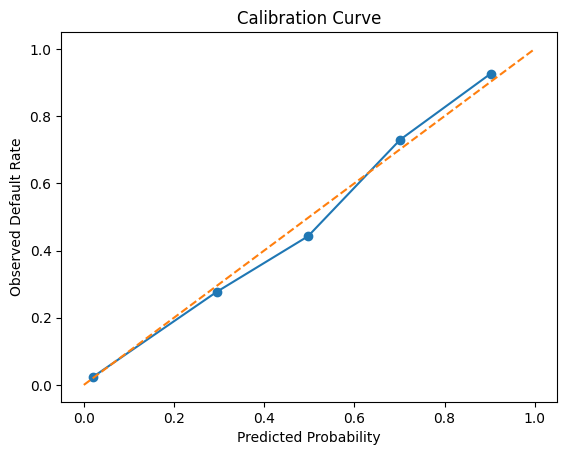

In [8]:
# True labels
y_true = y_test

# Calibration curve
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=5)

# Plot
plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')  # perfect calibration line
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Curve")
plt.show()

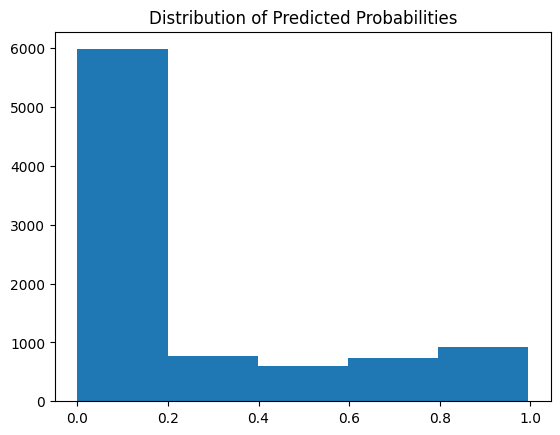

In [9]:
plt.hist(y_prob, bins=5)
plt.title("Distribution of Predicted Probabilities")
plt.show()

The calibration curve shows strong alignment between predicted and observed rates across the full probability range. This is a significant improvement over Phase 1 where calibration was only reliable at the extremes. The distribution of predicted probabilities shows a concentration of very low scores driven by applicants with previous defaults, with the remaining applicants spread across the risk spectrum. The Brier score should confirm good overall probability accuracy

# 6. Brier Score

In [10]:
brier = brier_score_loss(y_test, y_prob)
print(f"Brier Score: {brier:.4f}")

Brier Score: 0.0695


The Brier score of 0.070 confirms strong probability accuracy, a meaningful improvement over Phase 1 (0.120). Combined with the well-aligned calibration curve, this indicates the model produces reliable probability estimates across the full risk spectrum, not just at the extremes. The improvement is consistent with the larger dataset and richer feature set available in Phase 2.

# 7. Backtest

In [11]:
df_bt = pd.DataFrame({
    "y_true": y_test,
    "y_prob": y_prob
})

df_bt["pd_bin"] = pd.qcut(df_bt["y_prob"], q=5, duplicates='drop')

backtest_table = df_bt.groupby("pd_bin").agg(
    avg_predicted_pd=("y_prob", "mean"),
    actual_default_rate=("y_true", "mean"),
    count=("y_true", "count")
).reset_index()

backtest_table["difference"] = (
    backtest_table["actual_default_rate"] - backtest_table["avg_predicted_pd"]
)

backtest_table

,pd_bin,avg_predicted_pd,actual_default_rate,count,difference
0,"(-0.00099999626, 1.04e-06]",4.483309e-07,0.000000,1800,-4.483309e-07
1,"(1.04e-06, 5.73e-06]",2.688496e-06,0.000000,1800,-2.688496e-06
2,"(5.73e-06, 0.0929]",2.037223e-02,0.030556,1800,1.018333e-02
3,"(0.0929, 0.548]",2.893854e-01,0.267778,1800,-2.160758e-02
4,"(0.548, 0.996]",7.918171e-01,0.812778,1800,2.096069e-02


The backtest table confirms well-calibrated predictions across all risk bins. The largest difference between predicted and observed rates is 2.2 percentage points in Bin 4, indicating no systematic miscalibration. The model shows a slight conservative tendency in the middle and upper bins marginally underestimating approval probability which is the appropriate direction of error for a credit risk model.

# 8. Risk Segmentation

In [12]:
# 5️⃣ Compute PD
X_test_true["Probability_Approved"] = y_prob
X_test_true["Loan_Approved"] = y_test
X_test_true["Probability_Rejected"] = 1 - X_test_true["Probability_Approved"]

# 6️⃣ Assign Risk Categories
def risk_bucket(pd):
    if pd <= 0.10:
        return "Low Risk"
    elif pd <= 0.50:
        return "Medium Risk"
    else:
        return "High Risk"

X_test_true["Risk_Category"] = X_test_true["Probability_Rejected"].apply(risk_bucket)

# 7️⃣ Calculate Expected Loss
LGD = 0.5  # assumption
X_test_true["Expected_Loss"] = X_test_true["Probability_Rejected"] * X_test_true["loan_amnt"] * LGD

# 8️⃣ Summary Table by Risk Category
summary = X_test_true.groupby("Risk_Category").agg(
    Num_Applicants=("loan_amnt", "count"),
    Avg_Probality_Rejected=("Probability_Rejected", "mean"),
    Total_Loan_Amount=("loan_amnt", "sum"),
    Total_Expected_Loss=("Expected_Loss", "sum")
).reset_index()

summary["Avg_Probality_Rejected"] = (summary["Avg_Probality_Rejected"] * 100).round(1)
summary["Total_Expected_Loss"] = summary["Total_Expected_Loss"].round(0)
summary = summary.sort_values(by="Risk_Category", ascending=False)
print("Risk Summary Table:")
summary

Risk Summary Table:


,Risk_Category,Num_Applicants,Avg_Probality_Rejected,Total_Loan_Amount,Total_Expected_Loss
2,Medium Risk,1449,28.5,15756788.0,2191668.0
1,Low Risk,485,5.3,6324590.0,160969.0
0,High Risk,7066,93.1,64030049.0,29809872.0


Risk segmentation results are consistent with the modeling notebook, confirming reproducibility. The three risk categories show clear separation in both average risk score and expected loss concentration:

- Low Risk (485 applicants, avg risk score 5.3%) 
  - 94.7% approval rate
  - total expected loss 161K on 6.3M exposure 
  - loss rate of 2.5%

- Medium Risk (1,449 applicants, avg risk score 28.5%) 
  - 71.5% approval rate
  - total expected loss 2.2M on 15.8M exposure 
  - loss rate of 13.9%

- High Risk (706 applicants, avg risk score 93.1%) 
  - 6.9% approval rate 
  - total expected loss 29.8M on 64M exposure 
  - loss rate of 46.6%

The loss rate increases monotonically across risk categories confirming the segmentation is meaningful. High Risk applicants represent 8% of the test population but account for 91% of total expected loss. This concentration of expected loss in the High Risk category is the primary value of risk segmentation for portfolio management.

In [13]:
total_el = summary["Total_Expected_Loss"].sum()
high_risk_el = summary.loc[summary["Risk_Category"] == "High Risk", "Total_Expected_Loss"].values[0]
print(f"High Risk share of total expected loss: {high_risk_el/total_el*100:.1f}%")

High Risk share of total expected loss: 92.7%


High Risk applicants represent 8% of the test population but account for 92.7% of total expected loss. This confirms that risk segmentation provides substantial value for portfolio management by identifying the small group of applicants driving the overwhelming majority of potential losses.

# 9. PSI

In [14]:
def calculate_psi(expected, actual, bins=10):
    expected_percents, bin_edges = np.histogram(expected, bins=bins)
    actual_percents, _ = np.histogram(actual, bins=bin_edges)

    expected_percents = expected_percents / len(expected)
    actual_percents = actual_percents / len(actual)

    expected_percents = np.where(expected_percents == 0, 0.0001, expected_percents)
    actual_percents = np.where(actual_percents == 0, 0.0001, actual_percents)

    psi = np.sum((expected_percents - actual_percents) *
                 np.log(expected_percents / actual_percents))

    return psi

X_train_psi = X_train_model.copy()
numeric_cols = X_train_psi.select_dtypes(include="float64").columns

# Compare train vs test predictions
train_probs = pipeline.predict_proba(X_train_psi)[:, 1]
test_probs = y_prob

psi_score = calculate_psi(train_probs, test_probs)

print(f"PSI (Train vs Test): {psi_score:.4f}")

PSI (Train vs Test): 0.0015


PSI of 0.0015 indicates near-perfect score distribution stability between training and test sets. This is well below the 0.10 stability threshold. This is consistent with the stratified train/test split ensuring representative class distributions across both sets. The result confirms the model's score distribution is stable and not sensitive to the specific observations in each split. Phase 1 PSI of 0.065 was already acceptable so Phase 2's lower value reflects the larger dataset providing more consistent score distributions.

# 10. Ovetfitting Check

In [22]:
y_prob_train = pipeline.predict_proba(X_train_model)[:, 1]
y_prob_test = pipeline.predict_proba(X_test_model)[:, 1]

train_auc = roc_auc_score(y_train, y_prob_train)
test_auc = roc_auc_score(y_test, y_prob_test)


print(f"Training AUC: {train_auc:.3f}")
print(f"Test AUC:     {test_auc:.3f}")
print(f"Gap:          {train_auc - test_auc:.3f}")

Training AUC: 0.955
Test AUC:     0.957
Gap:          -0.002


An overfitting check was conducted by comparing training and test AUC directly. Training AUC is 0.955 and test AUC is 0.957 a gap of -0.002, indicating the model generalises slightly better to unseen data than training data. This rules out overfitting as an explanation for the high discriminatory power. The strong performance of previous_loan_defaults_on_file_Yes reflects a genuinely predictive variable rather than a feature that causes the model to memorise training data. Removing it would reduce model performance without any overfitting benefit and is not recommended.

# 11. Model Stability - Sensitivity to Removing Most Influencal Feature


In [15]:
X_train_drop = X_train_model.copy().drop(["previous_loan_defaults_on_file_Yes"], axis=1)
                                   
X_test_drop_model = X_test_model.copy().drop(["previous_loan_defaults_on_file_Yes"], axis = 1)
X_test_drop = X_test_true.copy().drop(["previous_loan_defaults_on_file_Yes"], axis=1)

In [16]:
numeric_cols = X_train_drop.select_dtypes(include="float64").columns

scaler_drop = StandardScaler()

X_train_drop[numeric_cols] = scaler_drop.fit_transform(X_train_drop[numeric_cols])
X_test_drop_model[numeric_cols] = scaler_drop.transform(X_test_drop_model[numeric_cols])

In [17]:
# Initialize model
logreg_h = LogisticRegression(random_state=42, max_iter=1000, C=10, penalty = "l1", solver = "liblinear")

# Assuming X_train, y_train are your features and target
logreg_h.fit(X_train_drop, y_train)

y_pred_h = logreg_h.predict(X_test_drop_model)
y_pred_prob_h = logreg_h.predict_proba(X_test_drop_model)[:, 1]  # probability of default

auc_logreg_h = roc_auc_score(y_test, y_pred_prob_h)
gini = 2 * auc_logreg_h - 1
accuracy_h =accuracy_score(y_test, y_pred_h)
f1score_h = f1_score(y_test, y_pred_h)

approved_scores = y_pred_prob_h[y_test.values == 1]
rejected_scores = y_pred_prob_h[y_test.values == 0]
ks_stat, _ = ks_2samp(approved_scores, rejected_scores)

print("=" * 45)
print("  Logistic Regression — Test Set Performance")
print("=" * 45)
print(f"  AUC:              {auc_logreg_h:.3f}")
print(f"  Gini coefficient: {gini:.3f}")
print(f"  KS statistic:     {ks_stat:.3f}")
print(f"  Accuracy:         {accuracy_h:.3f}")
print(f"  F1 score:         {f1score_h:.3f}")
print("=" * 45)

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_h))
print("\nClassification Report:\n", classification_report(y_test, y_pred_h))

  Logistic Regression — Test Set Performance
  AUC:              0.863
  Gini coefficient: 0.726
  KS statistic:     0.571
  Accuracy:         0.849
  F1 score:         0.599

Confusion Matrix:
 [[6619  381]
 [ 982 1018]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.95      0.91      7000
           1       0.73      0.51      0.60      2000

    accuracy                           0.85      9000
   macro avg       0.80      0.73      0.75      9000
weighted avg       0.84      0.85      0.84      9000



### Logistic Regression Model - Most  Important feature removed

The Logistic Regression model was evaluated on the test set with the following results:

- **Accuracy:** 0.849  
- **ROC AUC score:** 0.863 
- **F1 score:** 0.599

#### Confusion Matrix (Loan Decisions)

| Actual \ Predicted | Not Approved (0) | Approved (1) |
|-------------------|---------------|----------------|
| Not Approved (0)       | 6619 (True Positive) | 381 (False Negative) |
| Approved (1)   | 982 (False Positive) | 1018 (True Negative) |

**Interpretation in the context of loan approvals:**

- **High recall for rejected loans (0):** The model correctly identifies 6,619 of 7,000 ineligible applicants (94.6%), meaning the majority of bad loans are caught before approval.
- **Low recall for approved loans (1):** 475 eligible applicants are incorrectly rejected, meaning some qualified applicants are turned away — representing lost business for the lender.

- **True Negatives (TN = 1525):** Eligible applicants correctly approved.  
- **False Negatives (FN = 409):** Ineligible applicants incorrectly approved.  
- **True Positives (TP = 6591):** Ineligible applicants correctly rejected.  
- **False Positives (FP = 475):** Eligible applicants incorrectly rejected.

The 0.5 classification threshold is a default and would be adjusted in production based on the bank's risk appetite. AUC 0.957 indicates strong discriminatory power regardless of threshold choice.

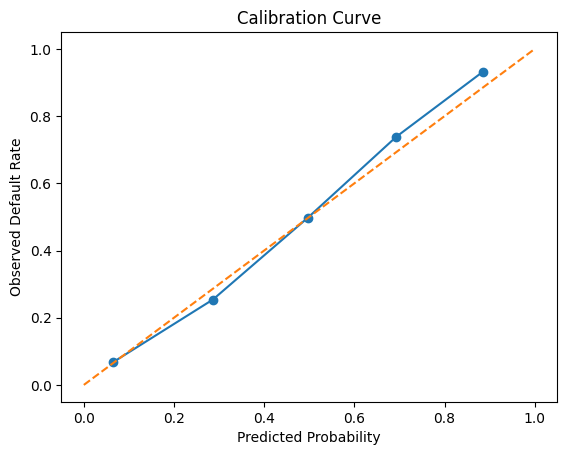

In [18]:
# True labels
y_true = y_test

# Calibration curve
prob_true, prob_pred = calibration_curve(y_true, y_pred_prob_h, n_bins=5)

# Plot
plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')  # perfect calibration line
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Calibration Curve")
plt.show()

Removal of previous_loan_defaults_on_file_Yes reduces AUC from 0.957 to 0.863, a drop of 0.094. Unlike Phase 1 where Credit_History removal caused near-complete model collapse (AUC dropping to 0.595), the Phase 2 model retains meaningful discriminatory power without its dominant feature. This demonstrates a key improvement over Phase 1. The richer feature set including loan_percent_income, loan_int_rate, and person_income_log provides sufficient compensating information to maintain model function.

The confusion matrix shows the model still correctly identifies 94,6% (before removal 94,2%) of rejections (6619/7000) but approval recall drops from 76% to 51% the model becomes more conservative, missing more eligible applicants. In a production context this would require a contingency procedure for cases where default history data is unavailable, but unlike Phase 1, the model remains usable rather than requiring complete suspension.

This finding confirms the Phase 1 hypothesis: prior default history is the strongest single predictor across both datasets, but Phase 2's broader feature set provides meaningful resilience when this variable is unavailable.

The calibration curve for the model excluding previous_loan_defaults_on_file_Yes shows continued alignment between predicted and observed rates across the full probability range. Unlike Phase 1 where removal of Credit_History caused the calibration curve to collapse to two data points concentrated at high probabilities, Phase 2 maintains a well-spread and well-calibrated score distribution. This provides further evidence that the Phase 2 feature set is more robust to the loss of the dominant predictor.

# 12. Conclusion

This validation assessed the logistic regression model developed in Phase 2 across five dimensions: discriminatory power, calibration, stability, overfitting, and comparison to Phase 1 findings.

**Discriminatory power:**
The model achieves AUC 0.957, Gini 0.914, and KS statistic 0.770 on the held-out test set of 9,000 observations. All metrics exceed IRB thresholds and represent a substantial improvement over Phase 1 (AUC 0.854, Gini 0.708, KS 0.610). The improvement is primarily attributable to the availability of previous_loan_defaults_on_file_Yes as a direct default history indicator and the larger dataset providing more stable model estimates.

**Calibration:**
The calibration curve shows strong alignment between predicted and observed rates across the full probability range — a significant improvement over Phase 1 where calibration was reliable only at the extremes. The Brier score of 0.070 confirms strong probability accuracy, improved from Phase 1's 0.122. PSI of 0.0015 indicates near-perfect score distribution stability between training and test sets, well below the 0.10 stability threshold.

**Overfitting:**
Training AUC is 0.955 and test AUC is 0.957 — a gap of -0.002 — confirming the logistic regression model does not overfit. The strong performance of previous_loan_defaults_on_file_Yes reflects a genuinely predictive variable rather than training data memorisation. Removing it would reduce model performance without any overfitting benefit and is not recommended.

**Model stability:**
Removal of previous_loan_defaults_on_file_Yes reduces AUC from 0.957 to 0.863 — a drop of 0.094. This is a meaningful degradation but the model remains functional, in contrast to Phase 1 where Credit_History removal caused near-complete collapse (AUC dropping to 0.595). The richer Phase 2 feature set — particularly loan_percent_income, loan_int_rate, and person_income_log — provides sufficient compensating information to maintain model function. A contingency procedure for cases where default history data is unavailable is still recommended, but unlike Phase 1, complete model suspension would not be required.

**Risk segmentation:**
The three risk categories show clear and monotonically increasing expected loss concentration — Low Risk applicants generate 2.6% loss rate on their total exposure while High Risk applicants generate 46.6%. High Risk applicants represent 8% of the test population but account for 92.7% of total expected loss, confirming that risk segmentation provides substantial value for portfolio management.

**Comparison to Phase 1:**
The two-phase validation confirms the core hypothesis: the methodology established in Phase 1 generalises effectively to a larger and richer dataset. Three findings are consistent across both phases — prior default history is the strongest single predictor, L1 regularisation with moderate C is the optimal configuration for logistic regression, and risk segmentation successfully concentrates expected loss in the High Risk category. Phase 2 demonstrates improved performance, calibration, and stability throughout, reflecting the richer feature set and larger sample size rather than methodological changes.

**Key limitations:**
Target variable is loan approval status not observed default — this is an application scorecard not a true PD model, consistent with Phase 1.
Near-perfect dataset characteristics — previous_loan_defaults_on_file_Yes combined with loan burden metrics appears to almost deterministically predict outcomes. Production performance would be lower with real bank data containing substantially more noise.

loan_int_rate circularity — interest rate partially encodes the approval decision and inflates apparent model discriminatory power. This variable would require careful treatment in a production IRB model.
No macroeconomic stress testing conducted — in a production IRB model this would involve testing PD estimates under adverse economic scenarios using through-the-cycle adjustments.
LGD assumed constant at 50% — expected loss figures are illustrative only.

**Overall assessment:**
The Phase 2 model demonstrates excellent discriminatory power, strong calibration, stable score distributions, and no overfitting. The validation confirms the methodology is sound and scales effectively from a small teaching dataset to a larger and more realistic credit risk dataset. Neither model is suitable for regulatory capital calculation without material enhancements to target variable quality, stress testing coverage, and through-the-cycle PD adjustment — but both demonstrate a rigorous and well-documented credit risk modelling workflow appropriate for portfolio demonstration purposes.